In [1]:
# ============================================================
# CELL 1 — Imports & Config
# ============================================================
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Mount Drive
drive.mount('/content/gdrive')

# ── CONFIG ──────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 4
SEED        = 42

# ⚠️ Set this to your actual dataset root in Drive
# Expected structure:
#   DATA_DIR/
#     healthy_leaves/
#     panama_wilt/
#     potassium_deficiency/
#     sigatoka/
DATA_DIR = '/content/gdrive/MyDrive/Banana_Leaf_Processed_Main'   # ← change if needed
# Cell 1 — update these path
TRAIN_DIR = os.path.join(DATA_DIR, 'split', 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'split', 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'split', 'test')

CLASS_NAMES = ['healthy_leaves', 'panama_wilt', 'potassium_deficiency', 'sigatoka']

PHASE1_EPOCHS   = 25   # frozen backbone
PHASE2_EPOCHS   = 20   # fine-tuning
FINETUNE_AT     = 80  # unfreeze layers from this index onward

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
# Cell 2 — replace flow_from_directory calls (no validation_split needed)
train_datagen = ImageDataGenerator(
    rescale             = 1./255,
    rotation_range      = 30,
    width_shift_range   = 0.15,
    height_shift_range  = 0.15,
    horizontal_flip     = True,
    vertical_flip       = True,
    zoom_range          = 0.25,
    shear_range         = 0.15,
    brightness_range    = [0.7, 1.3],
    channel_shift_range = 30.0,
    fill_mode           = 'reflect'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation on val

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASS_NAMES,
    seed        = SEED,
    shuffle     = True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASS_NAMES,
    seed        = SEED,
    shuffle     = False
)

test_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation on test

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASS_NAMES,
    seed        = SEED,
    shuffle     = False   # keep order for evaluation
)

print(f"✅ Classes : {train_gen.class_indices}")
print(f"   Train   : {train_gen.samples} images")
print(f"   Val     : {val_gen.samples} images")
print(f"   Test    : {test_gen.samples} images")

Found 1581 images belonging to 4 classes.
Found 396 images belonging to 4 classes.
Found 398 images belonging to 4 classes.
✅ Classes : {'healthy_leaves': 0, 'panama_wilt': 1, 'potassium_deficiency': 2, 'sigatoka': 3}
   Train   : 1581 images
   Val     : 396 images
   Test    : 398 images


In [3]:
# ============================================================
# CELL 3 — Class Weights (handles Panama wilt imbalance)
# ============================================================
labels = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(labels),
    y            = labels
)
class_weight_dict = {
    0: 1.0,   # healthy_leaves
    1: 1.2,   # panama_wilt
    2: 2.5,   # potassium_deficiency
    3: 1.3    # sigatoka
}
print("Class weights:", class_weight_dict)
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0, 1: 1.2, 2: 2.5, 3: 1.3}
Class weights: {0: 1.0, 1: 1.2, 2: 2.5, 3: 1.3}


In [4]:
# ============================================================
# CELL 4 — Model Definition
# ============================================================
def build_mobilenetv2(num_classes=NUM_CLASSES, trainable=False):
    base = MobileNetV2(
        input_shape = (IMG_SIZE, IMG_SIZE, 3),
        include_top = False,
        weights     = 'imagenet'
    )
    base.trainable = trainable   # frozen in Phase 1

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)          # BN layers stay in inference mode

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs), base

model, base_model = build_mobilenetv2()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,452 (10.01 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [5]:
# ============================================================
# CELL 5 — Callbacks (shared by both phases)
# ============================================================
SAVE_PATH = '/content/gdrive/MyDrive/banana_mobilenet_best.h5'

cb_list = [
    callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = 7,
        restore_best_weights = True,
        verbose              = 1
    ),
    callbacks.ModelCheckpoint(
        filepath         = SAVE_PATH,
        monitor          = 'val_accuracy',
        save_best_only   = True,
        verbose          = 1
    ),
    callbacks.ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-7,
        verbose   = 1
    )
]

In [6]:
# ============================================================
# CELL 6 — Phase 1: Train Head Only (frozen backbone)
# ============================================================
model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("=" * 50)
print("PHASE 1 — Training classification head (frozen backbone)")
print("=" * 50)

history1 = model.fit(
    train_gen,
    epochs           = PHASE1_EPOCHS,
    validation_data  = val_gen,
    class_weight     = class_weight_dict,
    callbacks        = cb_list,
    verbose          = 1
)

PHASE 1 — Training classification head (frozen backbone)
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step - accuracy: 0.4840 - loss: 1.9805
Epoch 1: val_accuracy improved from None to 0.75758, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 1: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6097 - loss: 1.5562 - val_accuracy: 0.7576 - val_loss: 0.7572 - learning_rate: 0.0010
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7131 - loss: 1.0995
Epoch 2: val_accuracy improved from 0.75758 to 0.80303, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 2: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 690ms/step - accuracy: 0.7103 - loss: 1.0950 - val_accuracy: 0.8030 - val_loss: 0.6505 - learning_rate: 0.0010
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.7565 - loss: 0.9759
Epoch 3: val_accuracy improved from 0.80303 to 0.81313, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 3: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 701ms/step - accuracy: 0.7729 - loss: 0.9157 - val_accuracy: 0.8131 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.7917 - loss: 0.8461
Epoch 4: val_accuracy did not improve from 0.81313
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 642ms/step - accuracy: 0.7900 - loss: 0.8757 - val_accuracy: 0.7980 - val_loss: 0.5339 - learning_rate: 0.0010
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.8069 - loss: 0.7539
Epoch 5: val_accuracy improved from 0.81313 to 0.82828, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 5: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 659ms/step - accuracy: 0.8128 - loss: 0.7813 - val_accuracy: 0.8283 - val_loss: 0.4881 - learning_rate: 0.0010
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.8210 - loss: 0.6922
Epoch 6: val_accuracy improved from 0.82828 to 0.86111, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5


...


Epoch 7: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 683ms/step - accuracy: 0.8299 - loss: 0.7283 - val_accuracy: 0.8813 - val_loss: 0.3803 - learning_rate: 0.0010
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8343 - loss: 0.6580
Epoch 8: val_accuracy did not improve from 0.88131
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 659ms/step - accuracy: 0.8273 - loss: 0.6920 - val_accuracy: 0.8813 - val_loss: 0.3664 - learning_rate: 0.0010
Epoch 9/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8222 - loss: 0.6956
Epoch 9: val_accuracy improved from 0.88131 to 0.90657, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 9: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 675ms/step - accuracy: 0.8368 - loss: 0.6698 - val_accuracy: 0.9066 - val_loss: 0.3419 - learning_rate: 0.0010
Epoch 10/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.8532 - loss: 0.6575
Epoch 10: val_accuracy did not improve from 0.90657
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 638ms/step - accuracy: 0.8476 - loss: 0.6817 - val_accuracy: 0.8763 - val_loss: 0.3832 - learning_rate: 0.0010
Epoch 11/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8501 - loss: 0.6262
Epoch 11: val_accuracy did not improve from 0.90657
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 643ms/step - accuracy: 0.8419 - loss: 0.6283 - val_accuracy: 0.8914 - val_loss: 0.3676 - learning_rate: 0.0010
Epoch 12/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.8654 - loss: 0.5849
Epoch 12: val_accuracy did not improve from 0.90657

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487


Epoch 21: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 669ms/step - accuracy: 0.8760 - loss: 0.5001 - val_accuracy: 0.9141 - val_loss: 0.3282 - learning_rate: 2.5000e-04
Epoch 22/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.8897 - loss: 0.4866
Epoch 22: val_accuracy improved from 0.91414 to 0.91667, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 22: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 675ms/step - accuracy: 0.8975 - loss: 0.4485 - val_accuracy: 0.9167 - val_loss: 0.3138 - learning_rate: 2.5000e-04
Epoch 23/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9082 - loss: 0.4527
Epoch 23: val_accuracy did not improve from 0.91667
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 643ms/step - accuracy: 0.9032 - loss: 0.4583 - val_accuracy: 0.9141 - val_loss: 0.3169 - learning_rate: 2.5000e-04
Epoch 24/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.9010 - loss: 0.4294
Epoch 24: val_accuracy did not improve from 0.91667
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 657ms/step - accuracy: 0.9001 - loss: 0.4423 - val_accuracy: 0.9141 - val_loss: 0.3075 - learning_rate: 2.5000e-04
Epoch 25/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8794 - loss: 0.5320
Epoch 25: val_accuracy improved from 0.91667 to 0.92172, saving model to /content/gdrive/MyDrive/banana_mobilene


Epoch 25: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 667ms/step - accuracy: 0.8950 - loss: 0.4654 - val_accuracy: 0.9217 - val_loss: 0.3082 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 24.


In [7]:
# ============================================================
# CELL 7 — Phase 2: Fine-tune top layers of MobileNetV2
# ============================================================
print(f"\nUnfreezing layers from index {FINETUNE_AT} onward …")
base_model.trainable = True

for layer in base_model.layers[:FINETUNE_AT]:
    layer.trainable = False
for layer in base_model.layers[FINETUNE_AT:]:
    # Keep BN in inference mode to avoid ruining pretrained stats
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

print(f"Trainable layers: {sum(l.trainable for l in model.layers)}")

# Lower LR is critical for fine-tuning
model.compile(
    optimizer = optimizers.Adam(learning_rate=5e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("\n" + "=" * 50)
print("PHASE 2 — Fine-tuning top MobileNetV2 layers")
print("=" * 50)

history2 = model.fit(
    train_gen,
    epochs           = PHASE2_EPOCHS,
    validation_data  = val_gen,
    class_weight     = class_weight_dict,
    callbacks        = cb_list,
    verbose          = 1
)


Unfreezing layers from index 80 onward …
Trainable layers: 9

PHASE 2 — Fine-tuning top MobileNetV2 layers
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8531 - loss: 0.6419
Epoch 1: val_accuracy did not improve from 0.92172
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8419 - loss: 0.6659 - val_accuracy: 0.8308 - val_loss: 0.5067 - learning_rate: 5.0000e-05
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8671 - loss: 0.5824
Epoch 2: val_accuracy did not improve from 0.92172
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 639ms/step - accuracy: 0.8640 - loss: 0.5863 - val_accuracy: 0.8409 - val_loss: 0.5258 - learning_rate: 5.0000e-05
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.8802 - loss: 0.5180
Epoch 3: val_accuracy did not improve from 0.92172

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 650ms/step - accuracy: 0.8792 - loss: 0.5140 - val_accuracy: 0.8258 - val_loss: 0.50


Epoch 4: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 714ms/step - accuracy: 0.9051 - loss: 0.4578 - val_accuracy: 0.9394 - val_loss: 0.2738 - learning_rate: 2.5000e-05
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9178 - loss: 0.3817
Epoch 5: val_accuracy did not improve from 0.93939
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 666ms/step - accuracy: 0.9089 - loss: 0.3934 - val_accuracy: 0.8889 - val_loss: 0.4300 - learning_rate: 2.5000e-05
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.9072 - loss: 0.3942
Epoch 6: val_accuracy did not improve from 0.93939
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 668ms/step - accuracy: 0.9171 - loss: 0.3660 - val_accuracy: 0.9369 - val_loss: 0.2472 - learning_rate: 2.5000e-05
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9284 - loss: 0.3603
Epoch 7: val_accuracy did not improve from 0.93939
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 641ms/step - accuracy: 0.9197 - loss


Epoch 10: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 708ms/step - accuracy: 0.9374 - loss: 0.3205 - val_accuracy: 0.9495 - val_loss: 0.2349 - learning_rate: 1.2500e-05
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9475 - loss: 0.2877
Epoch 11: val_accuracy did not improve from 0.94949
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 660ms/step - accuracy: 0.9437 - loss: 0.2811 - val_accuracy: 0.9470 - val_loss: 0.2277 - learning_rate: 1.2500e-05
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9366 - loss: 0.3325
Epoch 12: val_accuracy improved from 0.94949 to 0.95202, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 12: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 689ms/step - accuracy: 0.9336 - loss: 0.3330 - val_accuracy: 0.9520 - val_loss: 0.2210 - learning_rate: 1.2500e-05
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9428 - loss: 0.2915
Epoch 13: val_accuracy did not improve from 0.95202
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 659ms/step - accuracy: 0.9393 - loss: 0.3085 - val_accuracy: 0.9470 - val_loss: 0.2487 - learning_rate: 1.2500e-05
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.9510 - loss: 0.2839
Epoch 14: val_accuracy did not improve from 0.95202
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 661ms/step - accuracy: 0.9494 - loss: 0.2776 - val_accuracy: 0.9343 - val_loss: 0.2682 - learning_rate: 1.2500e-05
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9542 - loss: 0.2646
Epoch 15: val_accuracy did not improve from 0.95202
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 659ms/step - accuracy: 0.9456


Epoch 18: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5

Epoch 18: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 740ms/step - accuracy: 0.9500 - loss: 0.2727 - val_accuracy: 0.9545 - val_loss: 0.2214 - learning_rate: 1.2500e-05
Epoch 19/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.9466 - loss: 0.3211
Epoch 19: val_accuracy improved from 0.95455 to 0.95707, saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5



Epoch 19: finished saving model to /content/gdrive/MyDrive/banana_mobilenet_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 725ms/step - accuracy: 0.9475 - loss: 0.2957 - val_accuracy: 0.9571 - val_loss: 0.2066 - learning_rate: 6.2500e-06
Epoch 20/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.9602 - loss: 0.2372
Epoch 20: val_accuracy did not improve from 0.95707
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 650ms/step - accuracy: 0.9513 - loss: 0.2607 - val_accuracy: 0.9495 - val_loss: 0.2143 - learning_rate: 6.2500e-06
Restoring model weights from the end of the best epoch: 19.


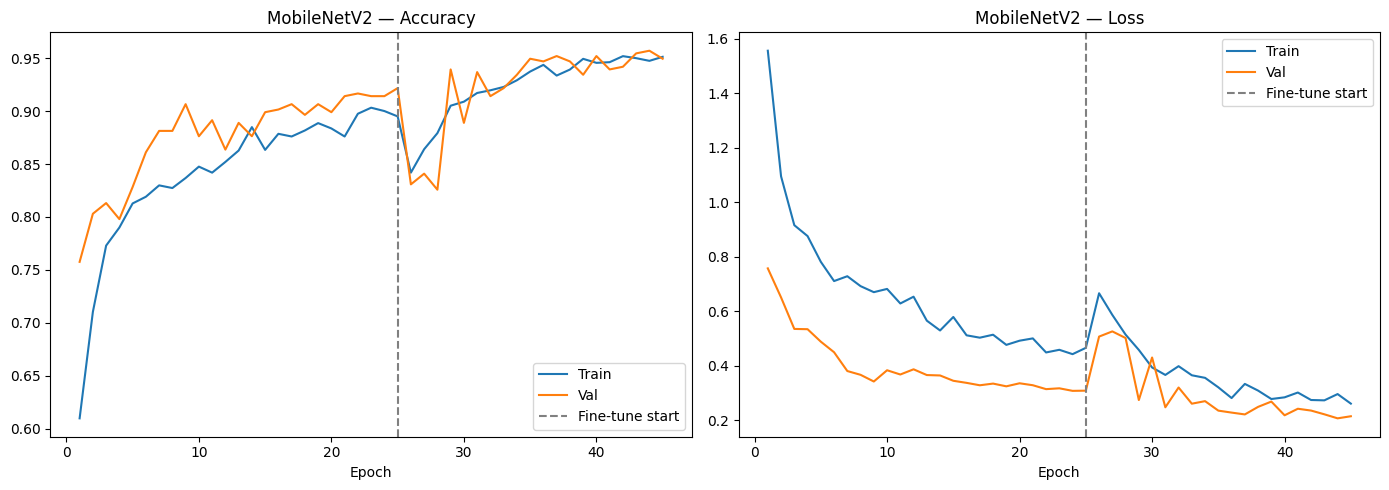

In [8]:
# ============================================================
# CELL 8 — Plot Training Curves
# ============================================================
def plot_history(h1, h2):
    # Merge both phase histories
    acc  = h1.history['accuracy']     + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']         + h2.history['loss']
    vloss= h1.history['val_loss']     + h2.history['val_loss']
    ep   = range(1, len(acc) + 1)
    sep  = len(h1.history['accuracy'])  # phase boundary

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, train_d, val_d, title in zip(
        axes,
        [acc, loss], [val, vloss],
        ['Accuracy', 'Loss']
    ):
        ax.plot(ep, train_d, label='Train')
        ax.plot(ep, val_d,   label='Val')
        ax.axvline(sep, color='gray', linestyle='--', label='Fine-tune start')
        ax.set_title(f'MobileNetV2 — {title}')
        ax.set_xlabel('Epoch'); ax.legend()
    plt.tight_layout(); plt.show()

plot_history(history1, history2)

13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step

Classification Report:
                      precision    recall  f1-score   support

      healthy_leaves       0.97      0.94      0.96       107
         panama_wilt       0.97      0.95      0.96       114
potassium_deficiency       0.90      0.98      0.94        92
            sigatoka       0.95      0.93      0.94        85

            accuracy                           0.95       398
           macro avg       0.95      0.95      0.95       398
        weighted avg       0.95      0.95      0.95       398



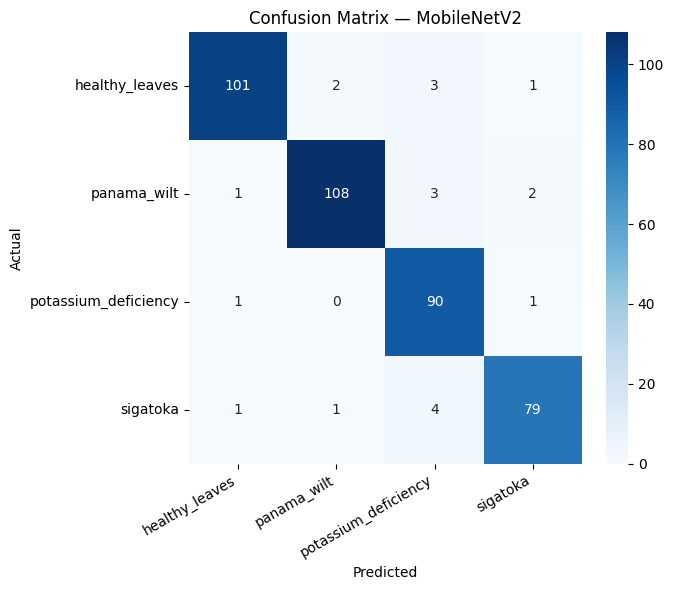

In [9]:
# Cell 9 — evaluate on TEST set (not val)
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — MobileNetV2')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

In [10]:
# Save the final model
model.save('/content/gdrive/MyDrive/banana_mobilenet_final.h5')
print("✅ Model saved and ready for deployment!")

✅ Model saved and ready for deployment!


In [1]:
# Search entire Drive for .h5 files
import os

search_root = '/content/gdrive/MyDrive'

print("🔍 Searching for .h5 files in Drive...\n")
found = []

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file.endswith('.h5') or file.endswith('.keras'):
            full_path = os.path.join(root, file)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            found.append(full_path)
            print(f"✅ Found: {full_path}")
            print(f"   Size : {size_mb:.1f} MB\n")

if not found:
    print("❌ No .h5 files found — model was not saved to Drive")
    print("   Check if it was saved locally to Colab instead:")
    for file in os.listdir('/content'):
        if file.endswith('.h5') or file.endswith('.keras'):
            size_mb = os.path.getsize(f'/content/{file}') / (1024 * 1024)
            print(f"   Found in Colab: /content/{file} ({size_mb:.1f} MB)")

🔍 Searching for .h5 files in Drive...

❌ No .h5 files found — model was not saved to Drive
   Check if it was saved locally to Colab instead:


In [2]:
# Check if model is still in memory
try:
    model.save('/content/gdrive/MyDrive/banana_dataset/banana_mobilenet_final.h5')
    print("✅ Model saved to Drive!")
except NameError:
    print("❌ Model not in memory — need to retrain")

❌ Model not in memory — need to retrain


In [3]:
from google.colab import drive
drive.mount('/content/gdrive')
import os

# Check if ModelCheckpoint saved anything during training
possible_paths = [
    '/content/gdrive/MyDrive/banana_mobilenet_best.h5',
    '/content/gdrive/MyDrive/banana_dataset/banana_mobilenet_best.h5',
    '/content/gdrive/MyDrive/banana_dataset/models_mobilenet',
]

print("🔍 Searching for any saved checkpoints...\n")
for p in possible_paths:
    if os.path.exists(p):
        size = os.path.getsize(p) / (1024*1024)
        print(f"✅ FOUND: {p}  ({size:.1f} MB)")
    else:
        print(f"❌ Not found: {p}")

# Also do a full search
print("\n🔍 Full Drive search for .h5 / .keras files...")
for root, dirs, files in os.walk('/content/gdrive/MyDrive'):
    for f in files:
        if f.endswith('.h5') or f.endswith('.keras'):
            full = os.path.join(root, f)
            size

MessageError: Error: credential propagation was unsuccessful

In [4]:
import os

save_path = '/content/drive/MyDrive/Banana_Leaf_Processed_Main/models/final_model.h5'
model.save(save_path)

size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"✅ Saved as .h5 → {save_path}")
print(f"   Size: {size_mb:.1f} MB")

NameError: name 'model' is not defined